#Fashin MNIST
Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

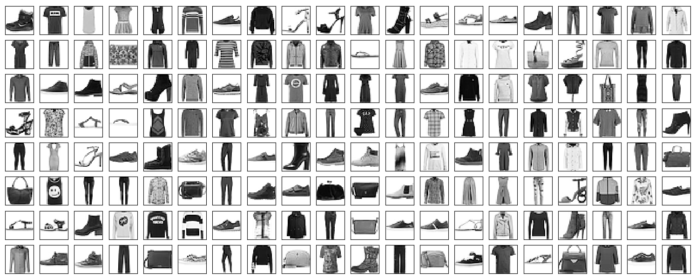


In [ ]:
from tensorflow.keras import datasets, layers, models, utils
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(x_train2d, y_train),(x_test2d, y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(x_train2d.shape, y_train.shape)
print(x_test2d.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [ ]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

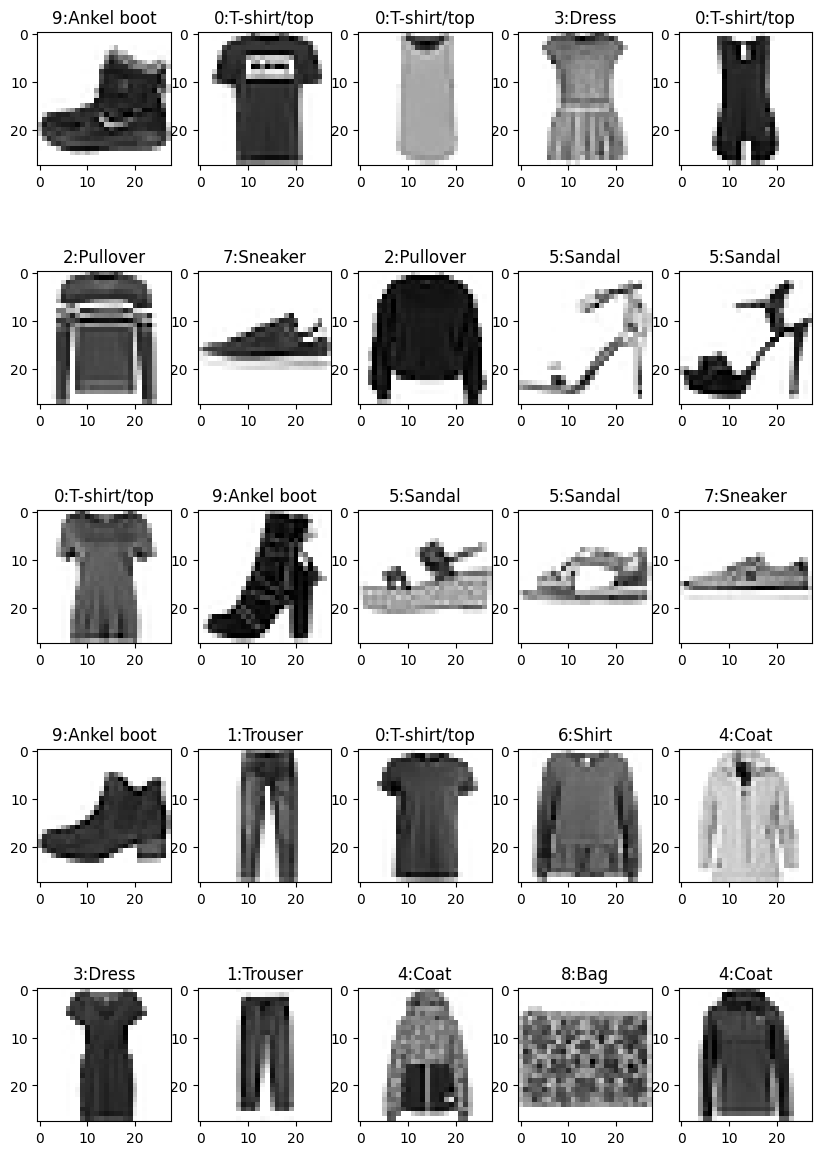

In [ ]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_train[i*5+j], items[y_train[i*5+j]]))
    axs[i, j].imshow(x_train2d[i*5+j], cmap='gray_r')
plt.show()

In [ ]:
# 채널추가
x_train = x_train2d.reshape(-1, 28, 28, 1)
x_test = x_test2d.reshape(-1, 28, 28, 1)

In [ ]:
# 정규화(0~1사이값으로 바꿔주는거)
x_train = x_train / 255
x_test = x_test / 255

#모델구성

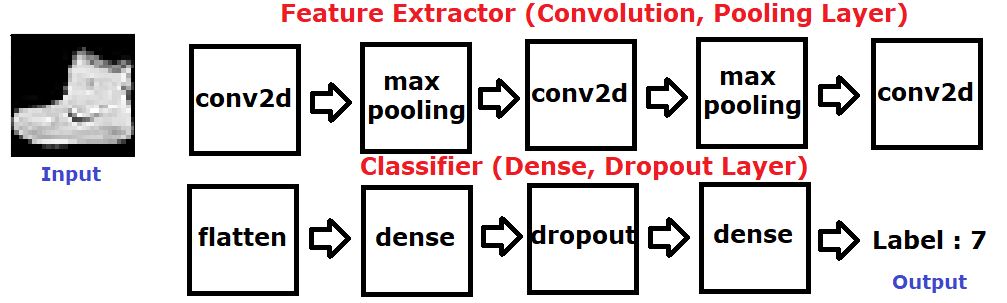

## Feature Extractor

In [ ]:
# 32 3*3, 64, 128 댄스층 128, 드롭아웃 0.3
model = models.Sequential()
#1
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
# max pooling(일반적으로 앞이랑 같음)
model.add(layers.MaxPooling2D((2,2), strides=2))
#3
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
# max pooling
model.add(layers.MaxPooling2D((2,2), strides=2))
#5
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))


In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

### Classifier

In [ ]:
# flatten
model.add(layers.Flatten())
# dense1
model.add(layers.Dense(128, activation='relu'))
# 과적합 방지
model.add(layers.Dropout(0.3))
#dense2
model.add(layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 컴파일
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

### 학습

In [ ]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - acc: 0.8321 - loss: 0.4632 - val_acc: 0.8876 - val_loss: 0.3059
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.8944 - loss: 0.2916 - val_acc: 0.8961 - val_loss: 0.2861
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9106 - loss: 0.2442 - val_acc: 0.9118 - val_loss: 0.2476
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9216 - loss: 0.2112 - val_acc: 0.9161 - val_loss: 0.2343
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9315 - loss: 0.1847 - val_acc: 0.9216 - val_loss: 0.2169
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9409 - loss: 0.1601 - val_acc: 0.9202 - val_loss: 0.2262
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9467 - loss: 0.1409 - val_acc: 0.9224 - val_loss: 0.2234
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9526 - loss: 0.1247 - val_acc: 0.9186 - val_loss: 0.2409
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━

In [ ]:
# 학습 곡선
def plot_history(history):
  plt.figure(figsize=(15,5))
  plt.subplot(1,2,1)
  plt.plot(history['acc'])
  plt.plot(history['val_acc'])
  plt.legend(['train','val'])
  plt.xlabel('epoch')
  plt.ylabel('Acc')

  plt.subplot(1,2,2)
  plt.plot(history['loss'])
  plt.plot(history['val_loss'])
  plt.legend(['train','val'])
  plt.xlabel('epoch')
  plt.ylabel('Loss')
  plt.show()

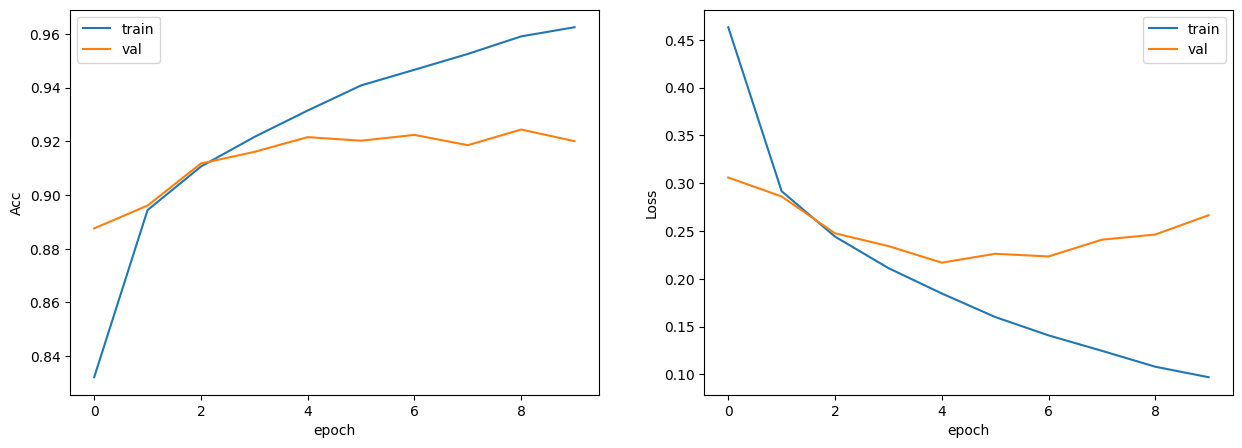

In [ ]:
plot_history(history.history)

#Drop out
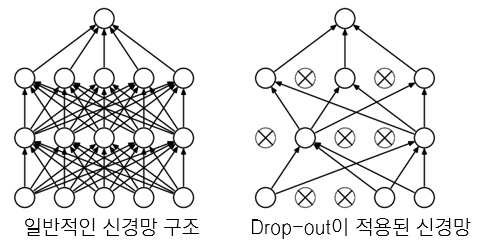

In [ ]:
# 과적합 방지 위에서 함 model.add(layers.Dropout(0.3))
# 실습 시 드롭아웃 여기서 하고, 러닝커브 비교

## BatchNormalization
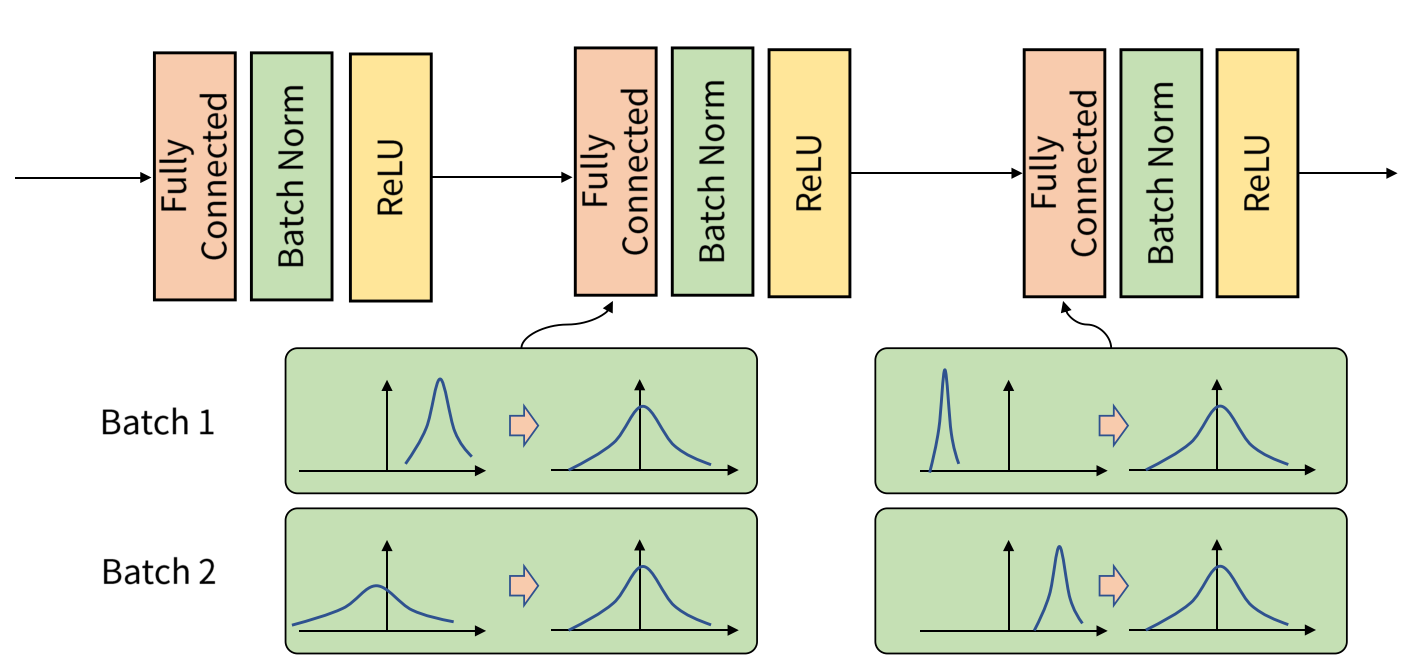

In [ ]:
model2 = models.Sequential()
#1
model2.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
# 배치 노멀라이제이션(과적합 방지)
model2.add(layers.BatchNormalization())

# max pooling(일반적으로 앞이랑 같음)
model2.add(layers.MaxPooling2D((2,2), strides=2))
#3
model2.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
# 배치 노멀라이제이션(과적합 방지)
model2.add(layers.BatchNormalization())


# max pooling
model2.add(layers.MaxPooling2D((2,2), strides=2))
#5
model2.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))

# flatten
model2.add(layers.Flatten())
# dense1
model2.add(layers.Dense(128, activation='relu'))
# 과적합 방지
model2.add(layers.Dropout(0.3))
#dense2
model2.add(layers.Dense(10, activation='softmax'))
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# 컴파일
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [ ]:
#학습
history = model2.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - acc: 0.8486 - loss: 0.4294 - val_acc: 0.8932 - val_loss: 0.2881
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.8983 - loss: 0.2876 - val_acc: 0.9003 - val_loss: 0.2599
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.9122 - loss: 0.2426 - val_acc: 0.9047 - val_loss: 0.2813
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9208 - loss: 0.2143 - val_acc: 0.9161 - val_loss: 0.2320
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9297 - loss: 0.1917 - val_acc: 0.8872 - val_loss: 0.3647
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9368 - loss: 0.1699 - val_acc: 0.9192 - val_loss: 0.2439
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9411 - loss: 0.1561 - val_acc: 0.9214 - val_loss: 0.2531
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9483 - loss: 0.1402 - val_acc: 0.9036 - val_loss: 0.2962
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━

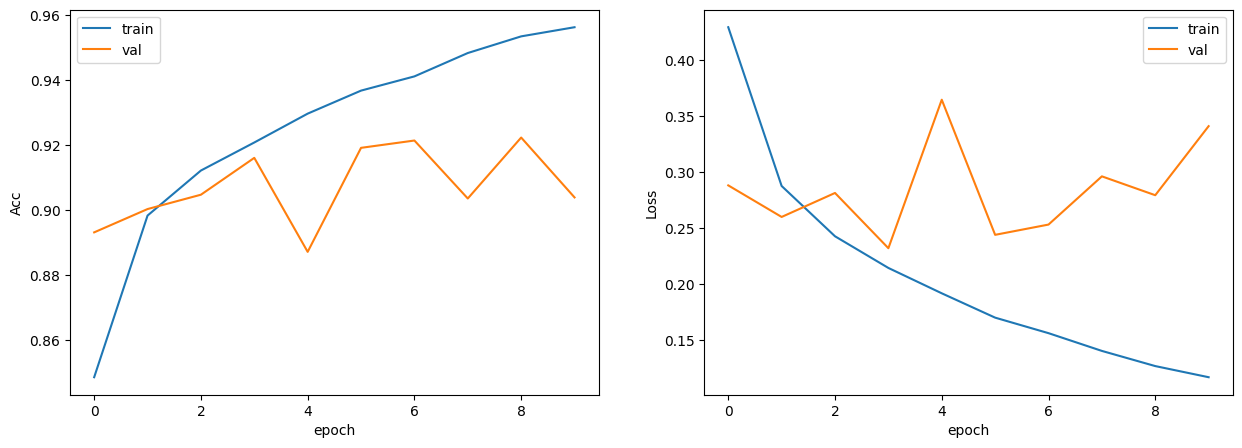

In [ ]:
plot_history(history.history)

In [ ]:
# 모델 평가
model2.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9009 - loss: 0.3449


[0.34490373730659485, 0.9009000062942505]

## Callback

In [ ]:
#모델 생성
model3 = models.Sequential()
model3.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model3.add(layers.BatchNormalization())   # 배치 노멀라이제이션(과적합 방지)
model3.add(layers.MaxPooling2D((2,2), strides=2)) # max pooling(일반적으로 앞이랑 같음)
model3.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model3.add(layers.BatchNormalization())   # 배치 노멀라이제이션(과적합 방지)
model3.add(layers.MaxPooling2D((2,2), strides=2)) # max pooling(일반적으로 앞이랑 같음)
model3.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))

model3.add(layers.Flatten())  # flatten
model3.add(layers.Dense(128, activation='relu'))    # dense1
model3.add(layers.Dropout(0.3)) # 과적합 방지
model3.add(layers.Dense(10, activation='softmax'))  #dense2
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)
history = model3.fit(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[checkpoint_cb])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - acc: 0.9593 - loss: 0.1117 - val_acc: 0.9193 - val_loss: 0.3218
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9644 - loss: 0.0945 - val_acc: 0.9197 - val_loss: 0.3348
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9665 - loss: 0.0926 - val_acc: 0.9225 - val_loss: 0.3109
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9682 - loss: 0.0854 - val_acc: 0.9217 - val_loss: 0.3366
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9711 - loss: 0.0791 - val_acc: 0.9197 - val_loss: 0.3640
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.9743 - loss: 0.0688 - val_acc: 0.9201 - val_loss: 0.3823
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - acc: 0.9730 - loss: 0.0756 - val_acc: 0.9220 - val_loss: 0.3429
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.9743 - loss: 0.0689 - val_acc: 0.9225 - val_loss: 0.3356
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━

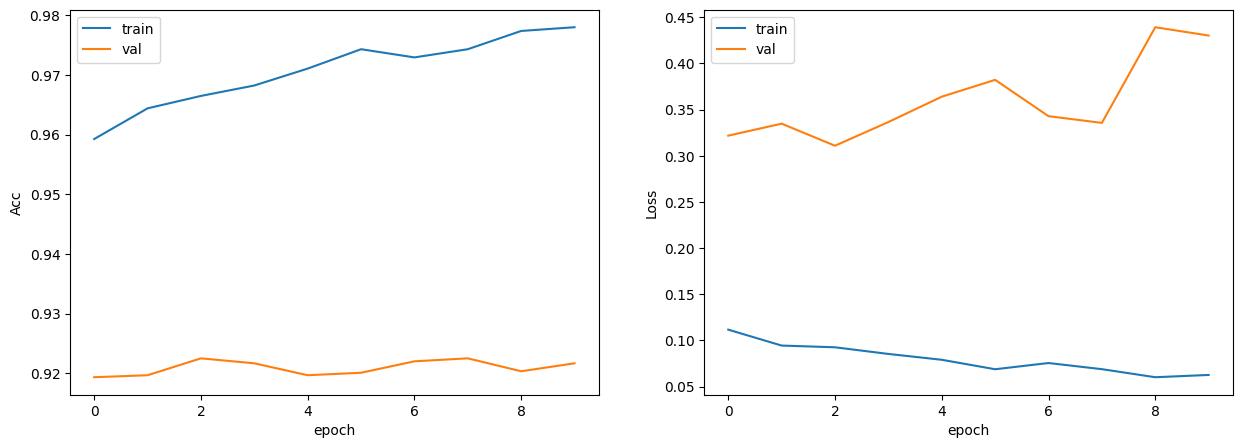

In [ ]:
plot_history(history.history)

In [ ]:
#콜백 2
#모델 생성
model4 = models.Sequential()
model4.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model4.add(layers.BatchNormalization())   # 배치 노멀라이제이션(과적합 방지)
model4.add(layers.MaxPooling2D((2,2), strides=2)) # max pooling(일반적으로 앞이랑 같음)
model4.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model4.add(layers.BatchNormalization())   # 배치 노멀라이제이션(과적합 방지)
model4.add(layers.MaxPooling2D((2,2), strides=2)) # max pooling(일반적으로 앞이랑 같음)
model4.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))

model4.add(layers.Flatten())  # flatten
model4.add(layers.Dense(128, activation='relu'))    # dense1
model4.add(layers.Dropout(0.3)) # 과적합 방지
model4.add(layers.Dense(10, activation='softmax'))  #dense2
model4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
model4.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [ ]:
# 콜백
checkpoint_cb = keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)
# (올라갔다가 내려가면 학습을 멈춰!) 인내를 몇번 참을까 하는게 패이션스 참다가 못참으면 스탑!
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model4.fit(x_test, y_test, epochs=10, validation_split=0.2, callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.8964 - loss: 0.2825 - val_acc: 0.8710 - val_loss: 0.3430
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9181 - loss: 0.2279 - val_acc: 0.8765 - val_loss: 0.3774
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9265 - loss: 0.1943 - val_acc: 0.8800 - val_loss: 0.3769
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9377 - loss: 0.1684 - val_acc: 0.8750 - val_loss: 0.4053


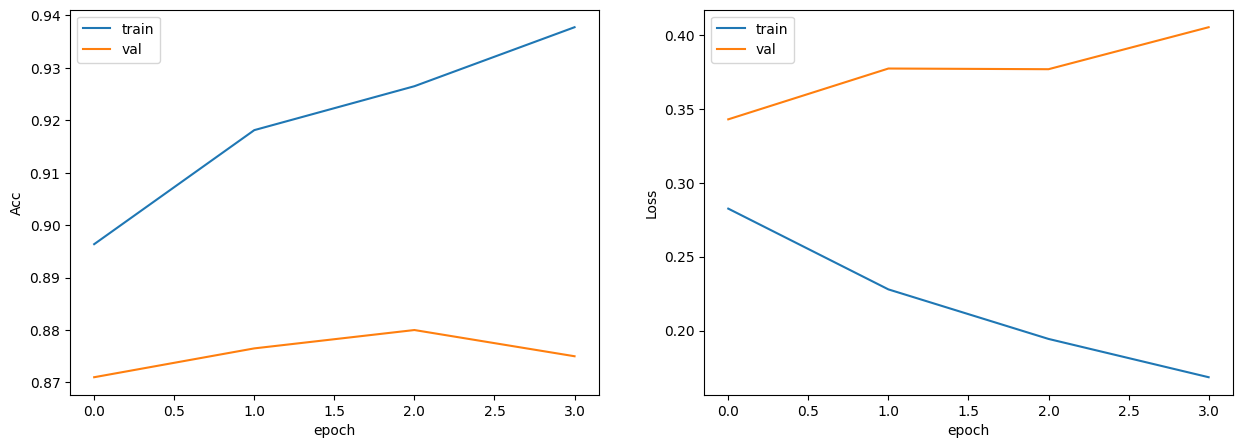

In [ ]:
plot_history(history.history)


In [ ]:
#예측
pred=model4.predict(x_test[0:25])
print(np.round(pred, decimals=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.    0.    0.    0.    0.    0.014 0.    0.102 0.    0.883]
 [0.    0.    1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.471 0.002 0.212 0.019 0.013 0.005 0.268 0.001 0.004 0.007]
 [0.021 0.977 0.    0.001 0.    0.    0.001 0.    0.    0.   ]
 [0.022 0.    0.187 0.002 0.668 0.    0.118 0.    0.002 0.   ]
 [0.001 0.001 0.046 0.002 0.184 0.    0.764 0.    0.001 0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.003 0.    0.997 0.    0.   ]
 [0.001 0.    0.06  0.    0.901 0.    0.037 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.999 0.    0.001 0.    0.   ]
 [0.    0.    0.    0.003 0.    0.892 0.    0.094 0.009 0.001]
 [0.007 0.053 0.003 0.923 0.004 0.001 0.008 0.    0.002 0.001]
 [0.001 0.001 0.032 0.001 0.943 0.    0.022 0.    0.    0.   ]
 [0.    1.    0. 

In [ ]:
np.argmax(pred, axis=1)

array([9, 2, 1, 1, 0, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4, 1, 2, 4, 8, 0, 2, 5,
       7, 9, 1])

In [ ]:
#답
print(y_test[0:25])

[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1]


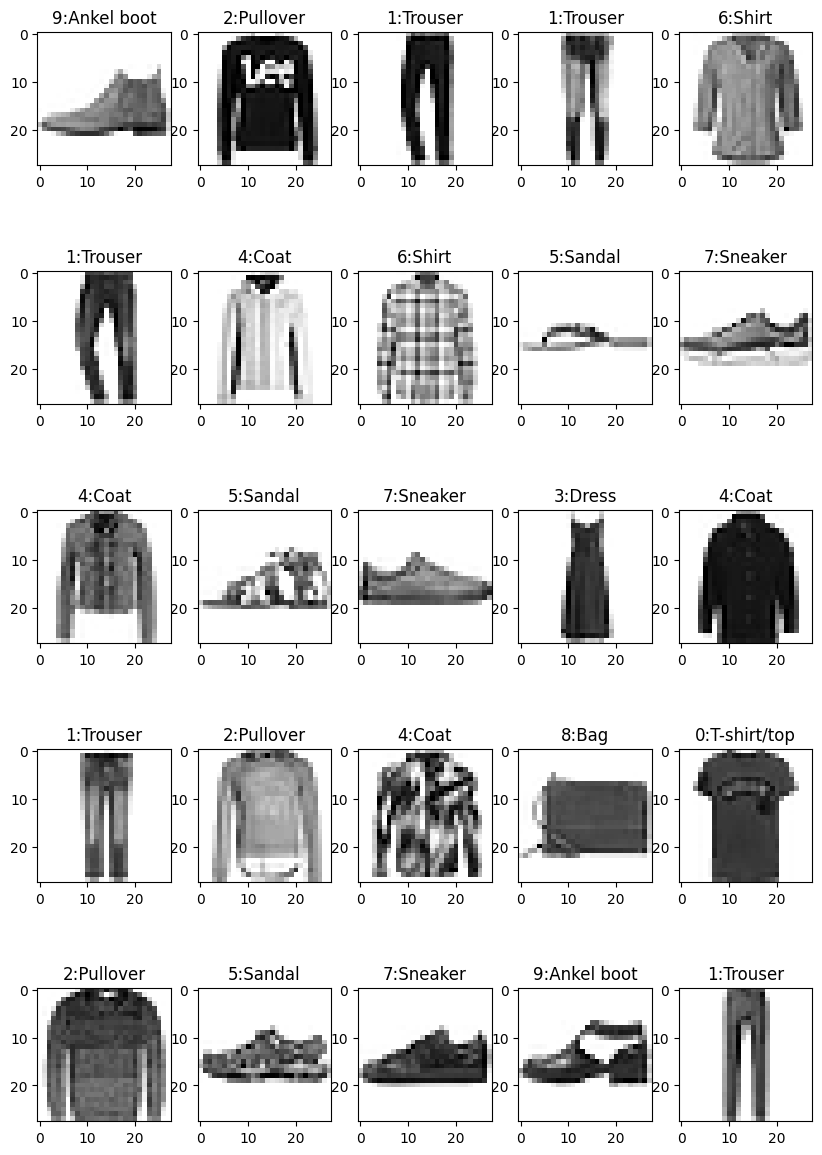

In [ ]:
# 왜 틀렸는지 확인
fig, axs = plt.subplots(5,5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i,j].set_title('{}:{}'.format(y_test[i*5+j], items[y_test[i*5+j]]))
    axs[i, j].imshow(x_test2d[i*5+j], cmap='gray_r')
plt.show()

## CNN의 시각화

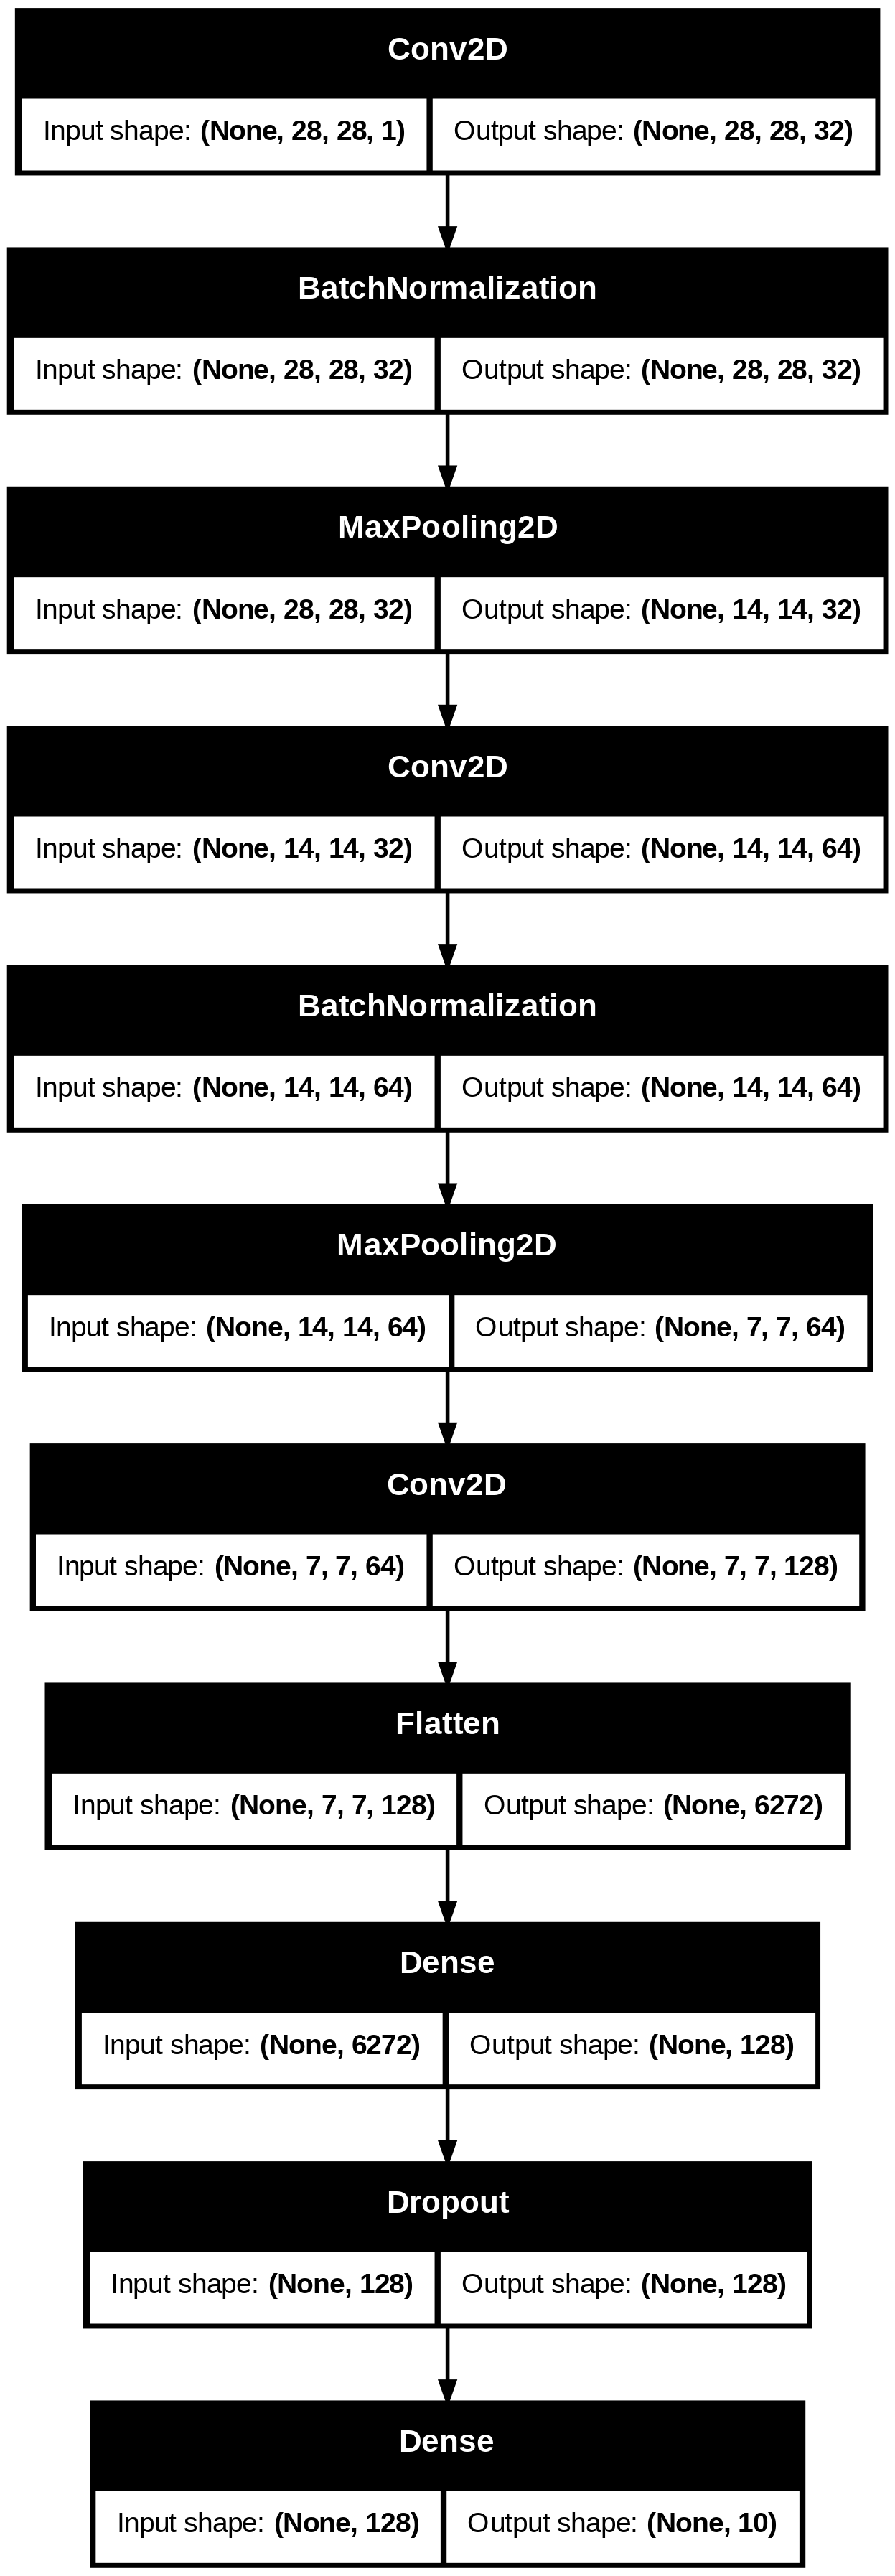

In [ ]:
utils.plot_model(model4, show_shapes=True, to_file='fmist.png')

### 학습된 Conv층 가져오기

In [ ]:
#모델4 레이어스
model4.layers

[<Conv2D name=conv2d_23, built=True>,
 <BatchNormalization name=batch_normalization_6, built=True>,
 <MaxPooling2D name=max_pooling2d_18, built=True>,
 <Conv2D name=conv2d_24, built=True>,
 <BatchNormalization name=batch_normalization_7, built=True>,
 <MaxPooling2D name=max_pooling2d_19, built=True>,
 <Conv2D name=conv2d_25, built=True>,
 <Flatten name=flatten_4, built=True>,
 <Dense name=dense_8, built=True>,
 <Dropout name=dropout_4, built=True>,
 <Dense name=dense_9, built=True>]

In [ ]:
# 레이어의 제일 처음
conv = model4.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [ ]:
# 학습되어있는 층 보기 웨이트[]4개
weigths = conv.weights[0].numpy()
print(weigths.shape)
print(weigths)

(3, 3, 1, 32)
[[[[ 0.04137614  0.13564384 -0.02302579  0.11167847 -0.15013847
     0.06562205 -0.08233903  0.01342596  0.12504773  0.0502429
    -0.24031438  0.09262439 -0.07099155  0.08493851  0.02985164
     0.12049679 -0.06873512 -0.09600873 -0.13957661  0.07591195
    -0.09258965  0.05270158  0.07181584  0.0592695   0.0513493
    -0.08072046  0.09926707  0.0302492   0.09759858 -0.12768503
    -0.01344824 -0.03538463]]

  [[ 0.0326932   0.02182453  0.09541826 -0.16084632  0.08708395
     0.09694754 -0.10244583 -0.07479504 -0.05923113 -0.03421669
    -0.06203596 -0.05101284  0.02217923  0.07509187 -0.03031925
    -0.0636046   0.15264215 -0.01433526  0.05430765 -0.12930176
     0.18428761  0.02069111  0.13613762 -0.12913013  0.0311846
    -0.06704758 -0.15097432  0.03539585  0.1193076   0.04453918
    -0.16171673 -0.10203333]]

  [[-0.02731007  0.04841555  0.10608119  0.08326445  0.06159145
    -0.05359574  0.05975664  0.04101766 -0.0470605   0.14230348
    -0.14595377 -0.04936301  0.

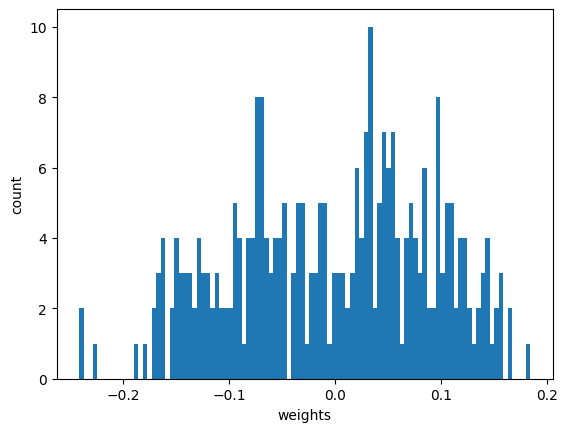

In [ ]:
#분석 (학습 후 분포가 되어 있는거 확인)
plt.hist(weigths.flatten(), bins=100)
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

In [ ]:
# 필터 그리기(3*3 , 1채널, 32필터)
weigths[:,:,0,0]  #첫번째 필터의 첫번째 채널 다가져오기

array([[ 0.04137614,  0.0326932 , -0.02731007],
       [-0.06700966, -0.02857043, -0.09729183],
       [-0.16745827,  0.15067996,  0.02333138]], dtype=float32)

In [ ]:
# 두번째 필터 나오게
weigths[:,:,0,2]

array([[-0.02302579,  0.09541826,  0.10608119],
       [ 0.14147258,  0.00672783, -0.0721118 ],
       [ 0.09682059,  0.14333412,  0.11794766]], dtype=float32)

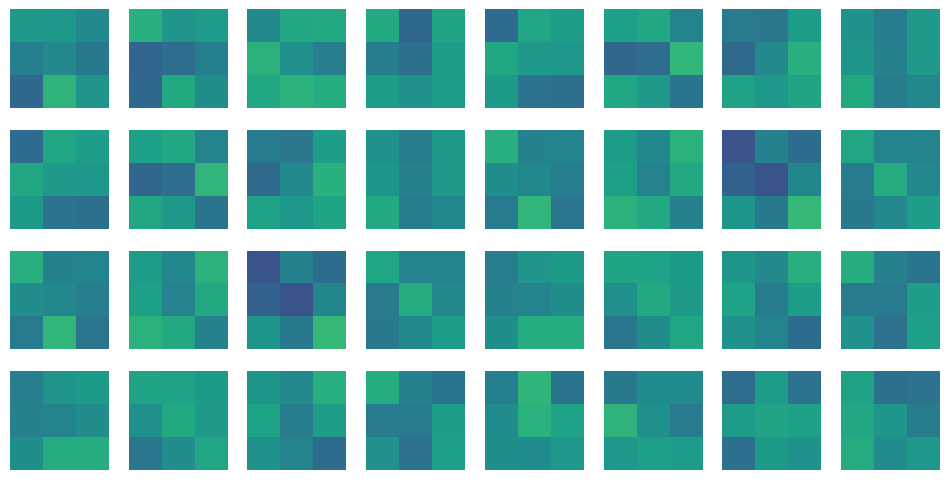

In [ ]:
# 확인
fig, axs = plt.subplots(4,8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    #axs[i,j].set_title('{}:{}'.format(y_test[i*5+j], items[y_test[i*5+j]]))
    axs[i, j].imshow(weigths[:,:,0, i*4+j], vmin=-0.5, vmax=0.5)  # -0.5 제일 어둡고, 0.5제일 밝고
    axs[i, j].axis('off') # 축안나오게
plt.show()

In [ ]:
# 학습안된 모델 확인 및 비교
init_model = keras.Sequential()
init_model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
init_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# shape 확인 (똑같아야 함)
new_conv = init_model.layers[0]
print(new_conv.weights[0].shape, new_conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [ ]:
# 넘파이로 변경
new_weights = new_conv.weights[0].numpy()
print(new_weights.shape)
print(new_weights)

(3, 3, 1, 32)
[[[[-0.04242997 -0.07680929 -0.1225758   0.06174463 -0.0955191
     0.01628894  0.06626955 -0.09623124  0.08953279  0.10866575
     0.06365551  0.06098767  0.023156   -0.0246994  -0.05134217
     0.02715583  0.00299303 -0.02113415  0.0482752   0.07145309
     0.00962403  0.00281268  0.02065843 -0.08325584 -0.04901493
     0.04635416 -0.03774156  0.07034542  0.08237277 -0.09496355
     0.01842459  0.09717835]]

  [[-0.12738106 -0.13376954 -0.08871716  0.13888209  0.08646826
     0.12117456 -0.0884665   0.00868258 -0.09043102  0.11177029
    -0.03962054  0.09476596  0.1269447   0.10494174  0.08893645
    -0.00939041 -0.11812429 -0.05513698  0.13924582 -0.03988252
     0.07654093  0.13852848  0.11659373  0.09291428 -0.04973852
    -0.11403006  0.05086805  0.03332877  0.05505954 -0.00959808
    -0.04014288  0.11142622]]

  [[-0.05211419  0.12280731 -0.10354485  0.09254833  0.13892151
    -0.00501478 -0.14076145 -0.08642584  0.03293501  0.0570101
     0.03302155 -0.09821352  0

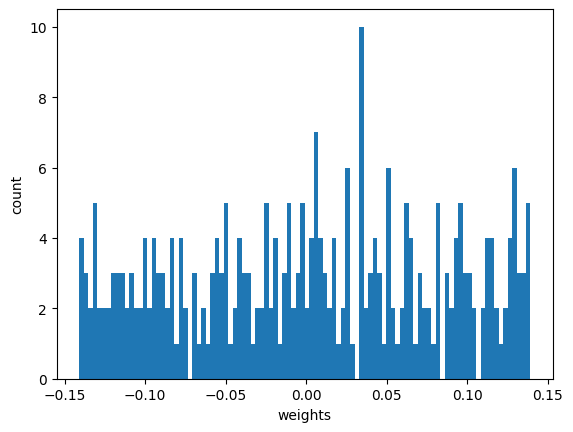

In [ ]:
#분석 (학습 후 분포가 되어 있는거 확인)
plt.hist(new_weights.flatten(), bins=100)
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

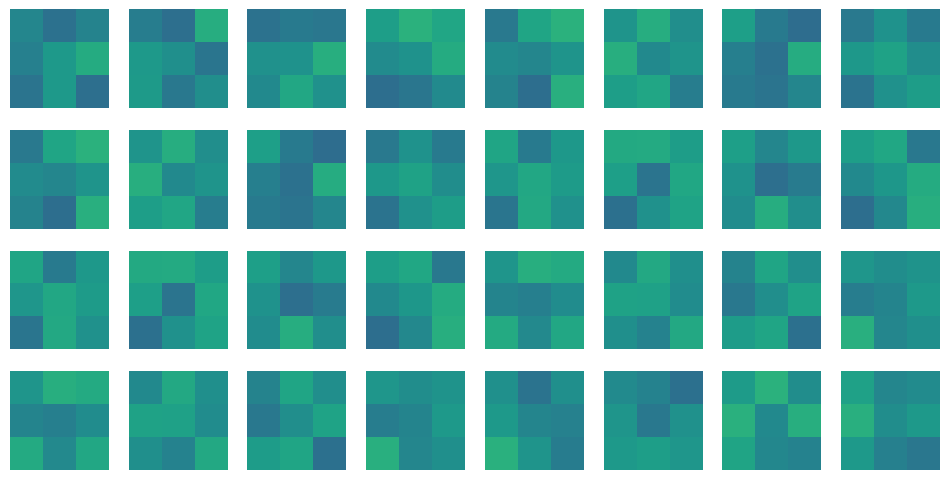

In [ ]:
# 확인
fig, axs = plt.subplots(4,8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    #axs[i,j].set_title('{}:{}'.format(y_test[i*5+j], items[y_test[i*5+j]]))
    axs[i, j].imshow(new_weights[:,:,0, i*4+j], vmin=-0.5, vmax=0.5)  # -0.5 제일 어둡고, 0.5제일 밝고
    axs[i, j].axis('off') # 축안나오게
plt.show()

### 필터를 거친 이미지 확인하기

In [ ]:
#모델 하나 만듬
conv1 = keras.Model(model4.inputs[0], model4.layers[0].output)
conv1.summary()

Model: "functional_70"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

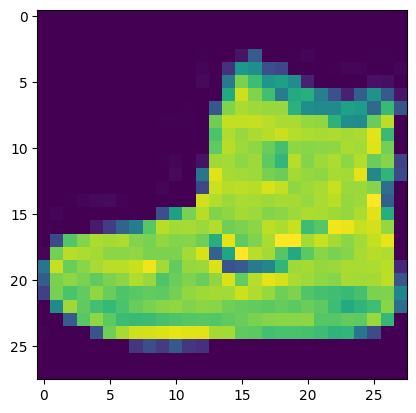

In [ ]:
plt.imshow(x_train2d[0])

In [ ]:
# 예측
# 전체가 어레이로 싸짐
feature_map1 = conv1.predict(x_train[0:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [ ]:
print(feature_map1.shape)

(1, 28, 28, 32)


In [ ]:
# 맨뒤(거쳐갈 필터번호)
feature_map1[0, :,:,2]

array([[0.01254674, 0.01254674, 0.01254674, 0.01254674, 0.01254674,
        0.01254674, 0.01254674, 0.01254674, 0.01254674, 0.01254674,
        0.01254674, 0.01254674, 0.01254674, 0.01254674, 0.01254674,
        0.01254674, 0.01254674, 0.01254674, 0.01254674, 0.01254674,
        0.01254674, 0.01254674, 0.01254674, 0.01254674, 0.01254674,
        0.01254674, 0.01254674, 0.01254674],
       [0.01254674, 0.01254674, 0.01254674, 0.01254674, 0.01254674,
        0.01254674, 0.01254674, 0.01254674, 0.01254674, 0.01254674,
        0.01254674, 0.01254674, 0.01254674, 0.01254674, 0.01254674,
        0.01254674, 0.01254674, 0.01254674, 0.01254674, 0.01254674,
        0.01254674, 0.01254674, 0.01254674, 0.01254674, 0.01254674,
        0.01254674, 0.01254674, 0.01254674],
       [0.01254674, 0.01254674, 0.01254674, 0.01254674, 0.01254674,
        0.01254674, 0.01254674, 0.01254674, 0.01254674, 0.01254674,
        0.01254674, 0.01300928, 0.01310883, 0.01292643, 0.01855975,
        0.05361938, 0.0585

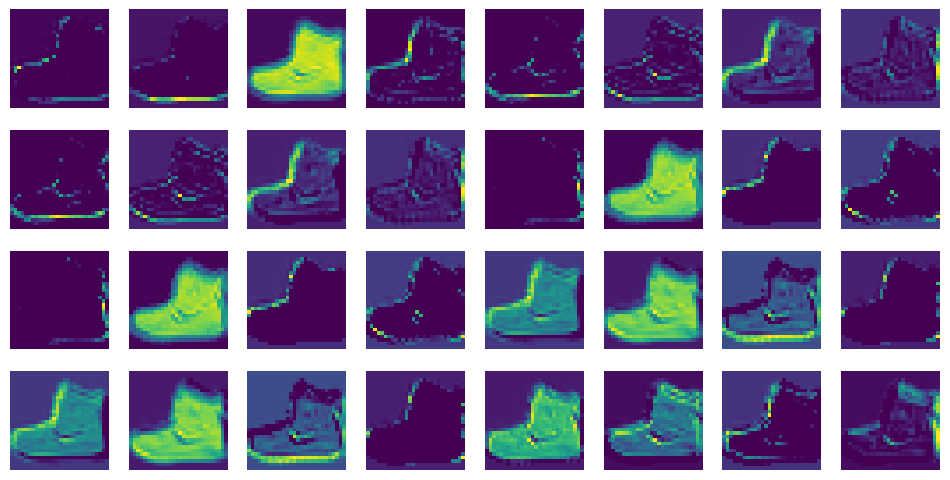

In [ ]:
# 확인 4열의 8칼럼
fig, axs = plt.subplots(4,8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    #axs[i,j].set_title('{}:{}'.format(y_test[i*5+j], items[y_test[i*5+j]]))
    axs[i, j].imshow(feature_map1[0,:,:, i*4+j])
    axs[i, j].axis('off') # 축안나오게
plt.show()

In [ ]:
model4.layers

[<Conv2D name=conv2d_23, built=True>,
 <BatchNormalization name=batch_normalization_6, built=True>,
 <MaxPooling2D name=max_pooling2d_18, built=True>,
 <Conv2D name=conv2d_24, built=True>,
 <BatchNormalization name=batch_normalization_7, built=True>,
 <MaxPooling2D name=max_pooling2d_19, built=True>,
 <Conv2D name=conv2d_25, built=True>,
 <Flatten name=flatten_4, built=True>,
 <Dense name=dense_8, built=True>,
 <Dropout name=dropout_4, built=True>,
 <Dense name=dense_9, built=True>]

In [ ]:
# 2번째 컴블리션 할때 어떻게 바뀌는지
con2 = keras.Model(model4.inputs[0], model4.layers[3].output) #4번째의 출력까지 가져옴
con2.summary()

Model: "functional_71"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,944 (74.00 KB)

 Trainable params: 18,880 (73.75 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
feature_map2 = con2.predict(x_train[0:1])
print(feature_map2.shape)
# 맥스 풀링이 있어서 반으로 줄음

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
(1, 14, 14, 64)


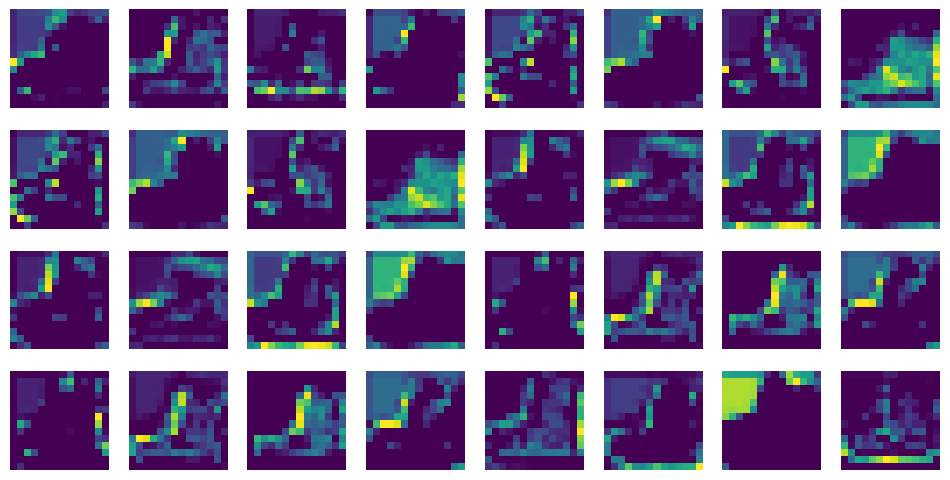

In [ ]:
# 확인 4열의 8칼럼, 전보다 강화된 픽쳐임
fig, axs = plt.subplots(4,8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    #axs[i,j].set_title('{}:{}'.format(y_test[i*5+j], items[y_test[i*5+j]]))
    axs[i, j].imshow(feature_map2[0,:,:, i*4+j])
    axs[i, j].axis('off') # 축안나오게
plt.show()

In [ ]:
model4.layers

[<Conv2D name=conv2d_23, built=True>,
 <BatchNormalization name=batch_normalization_6, built=True>,
 <MaxPooling2D name=max_pooling2d_18, built=True>,
 <Conv2D name=conv2d_24, built=True>,
 <BatchNormalization name=batch_normalization_7, built=True>,
 <MaxPooling2D name=max_pooling2d_19, built=True>,
 <Conv2D name=conv2d_25, built=True>,
 <Flatten name=flatten_4, built=True>,
 <Dense name=dense_8, built=True>,
 <Dropout name=dropout_4, built=True>,
 <Dense name=dense_9, built=True>]

In [ ]:
# 2번째 컴블리션 할때 어떻게 바뀌는지
con3 = keras.Model(model4.inputs[0], model4.layers[6].output) #4번째의 출력까지 가져옴
con3.summary()

Model: "functional_72"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,056 (363.50 KB)

 Trainable params: 92,864 (362.75 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
feature_map3 = con3.predict(x_train[0:1])
print(feature_map3.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
(1, 7, 7, 128)


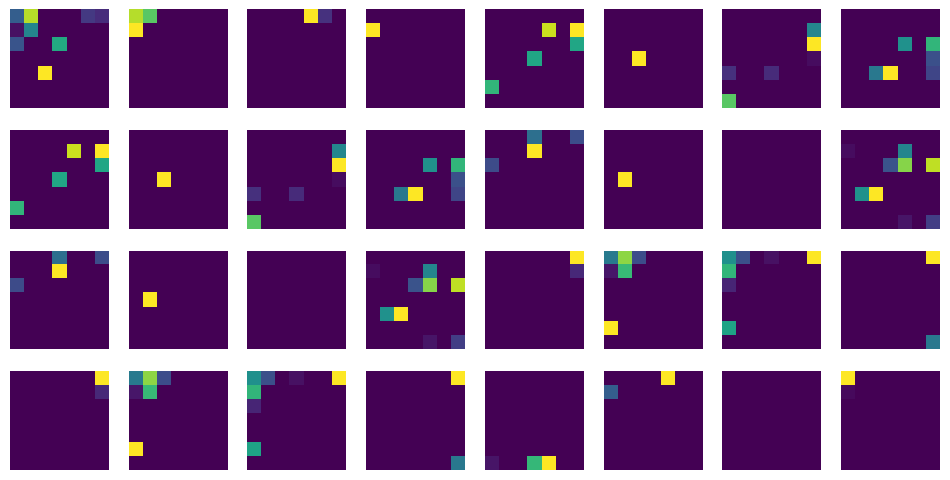

In [ ]:
# 확인 (4열의 8칼럼), 전보다 강화된 픽쳐임
fig, axs = plt.subplots(4,8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    #axs[i,j].set_title('{}:{}'.format(y_test[i*5+j], items[y_test[i*5+j]]))
    axs[i, j].imshow(feature_map3[0,:,:, i*4+j])
    axs[i, j].axis('off') # 축안나오게
plt.show()